In [1]:
include("CRD_STA.jl")
using Plots
using NonlinearEigenproblems
using FastGaussQuadrature

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,z,lam,kappa,D,D2
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [ ]:
N_cheb = 99
Ro = -1
Tw = 0.9
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

In [41]:
n = 30
num = 1
R = 300
omega = 0.0/R
be = n/R
Ma = Mr/R
c = 0.5
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
vel_full,vel = eig_full(eigvec,N_cheb,1)
A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 3 ,maxit = 500,tol = 1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.48570636096651043 + 0.006890713530467523im], ComplexF64[0.4857061777556171 + 0.00688471059731391im, 0.27566428121769304 + 0.06599944338112719im, 0.2974808347723506 + 0.12168810857522919im])


(ComplexF64[0.48570636096651043 + 0.006890713530467523im], ComplexF64[0.4857061777556171 + 0.00688471059731391im, 0.27566428121769304 + 0.06599944338112719im, 0.2974808347723506 + 0.12168810857522919im])

In [45]:
n = 30
num = 1
R = 320
omega = 0/R
be = n/R
Ma = Mr/R
eye = I(N_cheb + 1)
Zero = zeros(N_cheb + 1,N_cheb + 1)
if Ro == -1 
    Ro = 1
end
Ta_11 = Ta_12 = Ta_13 = Ta_15 = Ta_22 = Ta_23 = Ta_24 = Ta_25 = Ta_31 = Ta_33 = Ta_34 = Ta_35 = Ta_41 = Ta_42 = Ta_44 = Ta_45 = Ta_51 = Ta_52 = Ta_53 = Zero
Ta_14 = R * eye
Ta_21 = R .* rho .* eye
Ta_32 = R .* rho .* eye
Ta_43 = R .* rho .* eye
Ta_54 = (1-gamma)/(gamma) * R .*T .* eye
Ta_55 = 1/(gamma) * R .*rho .* eye

A_12 = A_13 = A_15 = A_22 = A_31 = A_33 = A_34 = A_35 = A_42 = A_44 = A_51 = A_52 = Zero
A_11 = R * rho .* eye
A_14 = R * F .* eye
A_21 = R * rho .* F .* eye
A_23 = - rho .* (D*T) .* eye
A_24 = (gamma*Ma^2)^(-1) * R .* T .* eye
A_25 = (gamma*Ma^2)^(-1) * R .* rho .* eye
A_32 = R * rho .* F .* eye
A_41 = -rho .* (D*lam) .* eye
A_43 = R * rho .* F .* eye
A_45 = - rho .* (D*F) .* eye
A_53 = -2 * (gamma-1) * Ma^2 * (D*F) .* eye 
A_54 = -(gamma-1)/(gamma) * R .* T .* F .* eye
A_55 = 1/gamma * R * rho .* F .* eye

B_11 = B_13 = B_15 = B_22 = B_23 = B_24 = B_25 = B_31 = B_41 = B_44 = B_51 = B_52 = Zero
dB_11 = dB_13 = dB_15 = dB_22 = dB_23 = dB_24 = dB_25 = dB_31 = dB_41 = dB_44 = dB_51 = dB_52 = Zero
B_12 = R* rho .* eye
dB_12 = R * (D*rho) .* eye
B_14 = R * G .* eye
dB_14 = R * (D*G) .* eye
B_21 = R * rho .* G .* eye
dB_21 = R * (D*rho) .* G .* eye + R * (D * G) .* rho .* eye
B_32 = R * rho .* G .* eye
dB_32 = R * (D*rho) .* G .* eye + R * (D * G) .* rho .* eye
B_33 = -rho .* (D*T) .* eye
dB_33 = -(D*rho) .* (D*T) .* eye - rho .* (D2*T) .* eye
B_34 = (gamma * Ma^2)^(-1)  * R .* T .* eye
dB_34 = (gamma * Ma^2)^(-1)  * R .* (D*T).*eye
B_35 = (gamma * Ma^2)^(-1)  * R .* rho .* eye
dB_35 = (gamma * Ma^2)^(-1)  * R .* (D*rho).*eye
B_42 = -rho .* (D*lam) .* eye
dB_42 = -(D*rho) .* (D*lam) .* eye - rho .* (D2*lam) .* eye
B_43 = R * rho .* G .* eye
dB_43 = R * (D*rho) .* G .* eye + R * (D * G) .* rho .* eye
B_45 = -rho .* (D*G) .* eye
dB_45 = -(D*rho).*(D*G).*eye - rho .* (D2*G).*eye
B_53 = -2 * (gamma-1) * Ma^2 * (D*G) .* eye
dB_53 = -2 * (gamma-1) * Ma^2 * (D2*G) .* eye
B_54 = -(gamma-1)/(gamma) * R * T .* G .* eye
dB_54 = -(gamma-1)/(gamma) * R * (T .* (D*G) + (D*T) .* G) .* eye
B_55 = 1/gamma * R .* rho .* G .* eye
dB_55 = 1/gamma * R .* (rho .* (D*G) + (D*rho) .* G) .* eye

C_11 = C_12 = C_15 = C_22 = C_23 = C_24 = C_31 = C_33 = C_34 = C_41 = C_42 = C_53 = Zero
dC_11 = dC_12 = dC_15 = dC_22 = dC_23 = dC_24 = dC_31 = dC_33 = dC_34 = dC_41 = dC_42 = dC_53 = Zero
C_13 = R * rho.^2 .* eye
# dC_13 = 2 * R * rho .* D * rho .* eye
dC_13 = D * diag(C_13) .* eye
C_14 = rho .* H .* eye
# dC_14 = D*rho .* H .* eye + rho .* (D*H) .* eye
dC_14 = D * diag(C_14) .* eye
C_21 = Ro * rho.^2 .* H .* eye
# dC_21 = Ro * (2 * rho .* (D*rho) .* H .+ rho.^2 .* (D*H) .* eye)
dC_21 = D * diag(C_21) .* eye
C_25 = -rho.^2 .* (D*F) .* eye
# dC_25 = -2 * rho .* (D*rho) .* (D*F) .* eye - rho.^2 .* (D2*F) .* eye
dC_25 = D * diag(C_25) .* eye
C_32 = Ro * rho.^2 .* H .* eye
# dC_32 = Ro * (2 * rho .* (D*rho) .* H .+ rho.^2 .* (D*H) .* eye)
dC_32 = D*diag(C_32) .* eye
C_35 = -rho.^2 .* (D*G) .* eye
# dC_35 = -2 * rho .* (D*rho) .* (D*G) .* eye - rho.^2 .* (D2*G) .* eye
dC_35 = D * diag(C_35) .* eye
C_43 = Ro * rho.^2 .* H .* eye
# dC_43 = Ro * (2 * rho .* (D*rho) .* H .+ rho.^2 .* (D*H) .* eye)
dC_43 = D * diag(C_43) .* eye
C_44 = R * (gamma * Ma^2)^(-1) * rho .* T .* eye
# dC_44 = R * (gamma * Ma^2)^(-1) * (rho .* (D*T) .+ (D*rho) .* T) .* eye
dC_44 = D * diag(C_44) .* eye
C_45 = R * (gamma * Ma^2)^(-1) * rho .* rho .* eye
# dC_45 = R * (gamma * Ma^2)^(-1) * (rho .* (D*rho) .+ (D*rho) .* rho) .* eye
dC_45 = D * diag(C_45) .* eye
C_51 = -2 * (gamma-1) * Ma^2 * rho .* (D*F) .* eye
# dC_51 = -2 * (gamma-1) * Ma^2 * (rho .* (D2*F) + (D*rho) .* (D*F)) .* eye
dC_51 = D * diag(C_51) .* eye
C_52 = -2 * (gamma-1) * Ma^2 * rho .* (D*G) .* eye
# dC_52 = -2 * (gamma-1) * Ma^2 * (rho .* (D2*G) + (D*rho) .* (D*G)) .* eye
dC_52 = D * diag(C_52) .* eye
C_54 = -(gamma-1)/gamma * rho .* H .* T .* eye
# dC_54 = -(gamma-1)/gamma * (rho .* (D*T) .* H .+ (D*rho) .* T .* H .+ rho .* (D*H) .* T).* eye
dC_54 = D * diag(C_54) .* eye
C_55 = 1/gamma * rho.^2 .* H .* eye + 1/sigma * rho.^2 .* (D*T) .* eye
# dC_55 = 1/gamma * (2 * rho .* (D*rho) .* H .+ rho.^2 .* (D*H) .* eye) + 1/sigma * (2 * rho .* (D*rho) .* (D*T) .+ rho.^2 .* (D2*T) .* eye)
dC_55 = D * diag(C_55) .* eye

D_12 = D_15 = D_41 = D_42 = D_51 = D_52 = Zero
D_11 = rho .* eye
D_13 = R * rho .* (D*rho) .* eye
D_14 = 2 * F .* eye + rho .* (D*H) .* eye
D_21 = Ro * rho .* F .* eye
D_22 = -rho .* (2* Ro * G .+ Co) .* eye
D_23 = R * rho.^2 .* (D*F) .* eye
D_24 = rho .* (D2*F) .* eye
D_25 = -rho .* D*(rho.*(D*F)) .* eye
D_31 = rho .* (2* Ro * G .+ Co) .* eye
D_32 = Ro * rho .* F .* eye
D_33 = R * rho.^2 .* (D*G) .* eye
D_34 = F .* (2* Ro * G .+ Co) .* eye + Ro * rho .* H .* (D*G) .* eye
D_35 = -rho.* (D * (rho .* (D*G))) .* eye
D_43 = Ro * rho.^2 .* (D*H) .* eye
D_44 = R * (gamma * Ma^2)^(-1) * rho .* (D*T) .* eye
D_45 = R * (gamma * Ma^2)^(-1) * rho .* (D*rho) .* eye
D_53 = R * rho.^2 .* (D*T) .* eye
D_54 = 1/gamma * rho .* H .* (D*T) .* eye
D_55 = -(gamma-1)/gamma * rho .* H .* (D*rho) .* eye - (1/sigma) * (rho .* (D*rho) .* (D*T) .+ rho.^2 .* (D2 * T)) .* eye - (gamma-1) * Ma^2 * rho.^2 .* ((D*F).^2 + (D*G).^2) .* eye

Vxx_11 = Vxx_12 = Vxx_13 = Vxx_15 = Vxx_22 = Vxx_23 = Vxx_24 = Vxx_25 = Vxx_31 = Vxx_33 = Vxx_34 = Vxx_35 = Vxx_41 = Vxx_42 = Vxx_44 = Vxx_45 = Vxx_51 = Vxx_52 = Vxx_53 = Vxx_54 = Zero
Vxx_14 = -1e-6 * eye
Vxx_21 = -(lam + 2*T) .* eye
Vxx_32 = -T .* eye
Vxx_43 = -T .* eye
Vxx_55 = -kappa .* eye

Vyy_11 = Vyy_12 = Vyy_13 = Vyy_14 = Vyy_15 = Vyy_22 = Vyy_23 = Vyy_24 = Vyy_25 = Vyy_31 = Vyy_33 = Vyy_34 = Vyy_35 = Vyy_41 = Vyy_42 = Vyy_44 = Vyy_45 = Vyy_51 = Vyy_52 = Vyy_53 = Vyy_54 = Zero
dVyy_11 = dVyy_12 = dVyy_13 = dVyy_14 = dVyy_15 = dVyy_22 = dVyy_23 = dVyy_24 = dVyy_25 = dVyy_31 = dVyy_33 = dVyy_34 = dVyy_35 = dVyy_41 = dVyy_42 = dVyy_44 = dVyy_45 = dVyy_51 = dVyy_52 = dVyy_53 = dVyy_54 = Zero
d2Vyy_11 = d2Vyy_12 = d2Vyy_13 = d2Vyy_14 = d2Vyy_15 = d2Vyy_22 = d2Vyy_23 = d2Vyy_24 = d2Vyy_25 = d2Vyy_31 = d2Vyy_33 = d2Vyy_34 = d2Vyy_35 = d2Vyy_41 = d2Vyy_42 = d2Vyy_44 = d2Vyy_45 = d2Vyy_51 = d2Vyy_52 = d2Vyy_53 = d2Vyy_54 = Zero
Vyy_21 = -T .* eye
dVyy_21 = -(D*T) .* eye
d2Vyy_21 = -(D2*T).*eye
Vyy_32 = -(lam .+ 2*T) .* eye
dVyy_32 = -(D*lam .+ 2*D*T) .* eye
d2Vyy_32 = -(D2*lam .+ 2*D2*T) .* eye
Vyy_43 = -T .* eye
dVyy_43 = -D*T.*eye
d2Vyy_43 = -D2*T .* eye
Vyy_55 = -kappa .* eye
dVyy_55 = -D*kappa .* eye
d2Vyy_55 = -D2*kappa .* eye

Vzz_11 = Vzz_12 = Vzz_13 = Vzz_14 = Vzz_15 = Vzz_22 = Vzz_23 = Vzz_24 = Vzz_25 = Vzz_31 = Vzz_33 = Vzz_34 = Vzz_35 = Vzz_41 = Vzz_42 = Vzz_44 = Vzz_45 = Vzz_51 = Vzz_52 = Vzz_53 = Vzz_54 = Zero
dVzz_11 = dVzz_12 = dVzz_13 = dVzz_14 = dVzz_15 = dVzz_22 = dVzz_23 = dVzz_24 = dVzz_25 = dVzz_31 = dVzz_33 = dVzz_34 = dVzz_35 = dVzz_41 = dVzz_42 = dVzz_44 = dVzz_45 = dVzz_51 = dVzz_52 = dVzz_53 = dVzz_54 = Zero
d2Vzz_11 = d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = d2Vzz_15 = d2Vzz_22 = d2Vzz_23 = d2Vzz_24 = d2Vzz_25 = d2Vzz_31 = d2Vzz_33 = d2Vzz_34 = d2Vzz_35 = d2Vzz_41 = d2Vzz_42 = d2Vzz_44 = d2Vzz_45 = d2Vzz_51 = d2Vzz_52 = d2Vzz_53 = d2Vzz_54 = Zero    
Vzz_21 = -rho .* eye
# dVzz_21 = -D*rho .* eye
# d2Vzz_21 = -D2*rho .* eye
dVzz_21 = D * diag(Vzz_21) .* eye
d2Vzz_21 = D2 * diag(Vzz_21) .* eye
Vzz_32 = -rho .* eye
# dVzz_32 = -D*rho .* eye
# d2Vzz_32 = -D2*rho .* eye
dVzz_32 = D * diag(Vzz_32) .* eye
d2Vzz_32 = D2 * diag(Vzz_32) .* eye
Vzz_43 = -rho .* (2 .+ lam .* rho) .* eye
# dVzz_43 = -2 * (D*rho) .* eye -2 * rho .* (D * rho) .* lam .* eye - rho.^2 .* (D * lam) .* eye
# d2Vzz_43 = -2 * (D2*rho) .* eye - 2 * (D * rho) .* (D * rho) .* lam .* eye - 2 * rho .* (D2 * rho) .* lam .* eye - 4 * rho .* (D * rho) .* (D * lam) .* eye - rho.^2 .* (D2 * lam) .* eye
dVzz_43 = D * diag(Vzz_43) .* eye
d2Vzz_43 = D2 * diag(Vzz_43) .* eye
Vzz_55 = -rho.^2 .* kappa .* eye
# dVzz_55 = -2 * rho .* (D * rho) .* kappa .* eye - rho.^2 .* (D * kappa) .* eye
# d2Vzz_55 = - 2 * (D * rho) .* (D * rho) .* kappa .* eye - 2 * rho .* (D2 * rho) .* kappa .* eye - 4 * rho .* (D * rho) .* (D * kappa) .* eye - rho.^2 .* (D2 * kappa) .* eye
dVzz_55 = D * diag(Vzz_55) .* eye
d2Vzz_55 = D2 * diag(Vzz_55) .* eye

Vxy_11 = Vxy_12 = Vxy_13 = Vxy_14 = Vxy_15 = Vxy_21 = Vxy_23 = Vxy_24 = Vxy_25 = Vxy_32 = Vxy_33 = Vxy_34 = Vxy_35 = Vxy_41 = Vxy_42  = Vxy_43 = Vxy_44 = Vxy_45 = Vxy_51 = Vxy_52 = Vxy_53 = Vxy_54 = Vxy_55 =  Zero
dVxy_11 = dVxy_12 = dVxy_13 = dVxy_14 = dVxy_15 = dVxy_21 = dVxy_23 = dVxy_24 = dVxy_25 = dVxy_32 = dVxy_33 = dVxy_34 = dVxy_35 = dVxy_41 = dVxy_42  = dVxy_43 = dVxy_44 = dVxy_45 = dVxy_51 = dVxy_52 = dVxy_53 = dVxy_54 = dVxy_55 =  Zero

Vxy_22 = -(lam .+ T) .* eye
dVxy_22 = -(D*lam .+ D*T) .* eye
Vxy_31 = -(lam .+ T) .* eye
dVxy_31 = -(D*lam .+ D*T) .* eye

Vxz_11 = Vxz_12 = Vxz_13 = Vxz_14 = Vxz_15 = Vxz_21 = Vxz_22 = Vxz_24 = Vxz_25 = Vxz_31 = Vxz_32 = Vxz_33 = Vxz_34 = Vxz_35 = Vxz_42 = Vxz_43 = Vxz_44 = Vxz_45 = Vxz_51 = Vxz_52 = Vxz_53 = Vxz_54 = Vxz_55 =  Zero
dVxz_11 = dVxz_12 = dVxz_13 = dVxz_14 = dVxz_15 = dVxz_21 = dVxz_22 = dVxz_24 = dVxz_25 = dVxz_31 = dVxz_32 = dVxz_33 = dVxz_34 = dVxz_35 = dVxz_42 = dVxz_43 = dVxz_44 = dVxz_45 = dVxz_51 = dVxz_52 = dVxz_53 = dVxz_54 = dVxz_55 =  Zero
Vxz_23 = - (1 .+ rho.*lam) .* eye
# dVxz_23 = - (D*rho.*lam .+ rho.*D*lam) .* eye
dVxz_23 = D * diag(Vxz_23) .* eye
Vxz_41 = - (1 .+ rho.*lam) .* eye
# dVxz_41 = - (D*rho.*lam .+ rho.*D*lam) .* eye
dVxz_41 = D * diag(Vxz_41) .* eye

Vyz_11 = Vyz_12 = Vyz_13 = Vyz_14 = Vyz_15 = Vyz_21 = Vyz_22 = Vyz_23 = Vyz_24 = Vyz_25 = Vyz_31 = Vyz_32  = Vyz_34 = Vyz_35 = Vyz_41 = Vyz_43 = Vyz_44 = Vyz_45 = Vyz_51 = Vyz_52 = Vyz_53 = Vyz_54 = Vyz_55 =  Zero
dVyz_11 = dVyz_12 = dVyz_13 = dVyz_14 = dVyz_15 = dVyz_21 = dVyz_22 = dVyz_23 = dVyz_24 = dVyz_25 = dVyz_31 = dVyz_32  = dVyz_34 = dVyz_35 = dVyz_41 = dVyz_43 = dVyz_44 = dVyz_45 = dVyz_51 = dVyz_52 = dVyz_53 = dVyz_54 = dVyz_55 =  Zero
Vyz_33 = - (1 .+ rho.*lam) .* eye
# dVyz_33 = - (D*rho.*lam .+ rho.*D*lam) .* eye
dVyz_33 = D * diag(Vyz_33) .* eye
Vyz_42 = - (1 .+ rho.*lam) .* eye
# dVyz_42 = - (D*rho.*lam .+ rho.*D*lam) .* eye
dVyz_42 = D * diag(Vyz_42) .* eye

Ta = [Ta_14 Ta_11 Ta_12 Ta_13 Ta_15;Ta_24 Ta_21 Ta_22 Ta_23 Ta_25;Ta_34 Ta_31 Ta_32 Ta_33 Ta_35;Ta_44 Ta_41 Ta_42 Ta_43 Ta_45;Ta_54 Ta_51 Ta_52 Ta_53 Ta_55]

A = [A_14 A_11 A_12 A_13 A_15;A_24 A_21 A_22 A_23 A_25;A_34 A_31 A_32 A_33 A_35;A_44 A_41 A_42 A_43 A_45;A_54 A_51 A_52 A_53 A_55]

B = [B_14 B_11 B_12 B_13 B_15;B_24 B_21 B_22 B_23 B_25;B_34 B_31 B_32 B_33 B_35;B_44 B_41 B_42 B_43 B_45;B_54 B_51 B_52 B_53 B_55]

C = [C_14 C_11 C_12 C_13 C_15;C_24 C_21 C_22 C_23 C_25;C_34 C_31 C_32 C_33 C_35;C_44 C_41 C_42 C_43 C_45;C_54 C_51 C_52 C_53 C_55]

dC = [dC_14 dC_11 dC_12 dC_13 dC_15;dC_24 dC_21 dC_22 dC_23 dC_25;dC_34 dC_31 dC_32 dC_33 dC_35;dC_44 dC_41 dC_42 dC_43 dC_45;dC_54 dC_51 dC_52 dC_53 dC_55]

D1 = [D_14 D_11 D_12 D_13 D_15;D_24 D_21 D_22 D_23 D_25;D_34 D_31 D_32 D_33 D_35;D_44 D_41 D_42 D_43 D_45;D_54 D_51 D_52 D_53 D_55]

Vxx = [Vxx_14 Vxx_11 Vxx_12 Vxx_13 Vxx_15;Vxx_24 Vxx_21 Vxx_22 Vxx_23 Vxx_25;Vxx_34 Vxx_31 Vxx_32 Vxx_33 Vxx_35;Vxx_44 Vxx_41 Vxx_42 Vxx_43 Vxx_45;Vxx_54 Vxx_51 Vxx_52 Vxx_53 Vxx_55]

Vyy = [Vyy_14 Vyy_11 Vyy_12 Vyy_13 Vyy_15;Vyy_24 Vyy_21 Vyy_22 Vyy_23 Vyy_25;Vyy_34 Vyy_31 Vyy_32 Vyy_33 Vyy_35;Vyy_44 Vyy_41 Vyy_42 Vyy_43 Vyy_45;Vyy_54 Vyy_51 Vyy_52 Vyy_53 Vyy_55]

Vzz = [Vzz_14 Vzz_11 Vzz_12 Vzz_13 Vzz_15;Vzz_24 Vzz_21 Vzz_22 Vzz_23 Vzz_25;Vzz_34 Vzz_31 Vzz_32 Vzz_33 Vzz_35;Vzz_44 Vzz_41 Vzz_42 Vzz_43 Vzz_45;Vzz_54 Vzz_51 Vzz_52 Vzz_53 Vzz_55]

dVzz = [dVzz_14 dVzz_11 dVzz_12 dVzz_13 dVzz_15;dVzz_24 dVzz_21 dVzz_22 dVzz_23 dVzz_25;dVzz_34 dVzz_31 dVzz_32 dVzz_33 dVzz_35;dVzz_44 dVzz_41 dVzz_42 dVzz_43 dVzz_45;dVzz_54 dVzz_51 dVzz_52 dVzz_53 dVzz_55]

d2Vzz = [d2Vzz_14 d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_15;d2Vzz_24 d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_25;d2Vzz_34 d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_35;d2Vzz_44 d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_45;d2Vzz_54 d2Vzz_51 d2Vzz_52 d2Vzz_53 d2Vzz_55]

Vxy = [Vxy_14 Vxy_11 Vxy_12 Vxy_13 Vxy_15;Vxy_24 Vxy_21 Vxy_22 Vxy_23 Vxy_25;Vxy_34 Vxy_31 Vxy_32 Vxy_33 Vxy_35;Vxy_44 Vxy_41 Vxy_42 Vxy_43 Vxy_45;Vxy_54 Vxy_51 Vxy_52 Vxy_53 Vxy_55]

Vxz = [Vxz_14 Vxz_11 Vxz_12 Vxz_13 Vxz_15;Vxz_24 Vxz_21 Vxz_22 Vxz_23 Vxz_25;Vxz_34 Vxz_31 Vxz_32 Vxz_33 Vxz_35;Vxz_44 Vxz_41 Vxz_42 Vxz_43 Vxz_45;Vxz_54 Vxz_51 Vxz_52 Vxz_53 Vxz_55]

dVxz = [dVxz_14 dVxz_11 dVxz_12 dVxz_13 dVxz_15;dVxz_24 dVxz_21 dVxz_22 dVxz_23 dVxz_25;dVxz_34 dVxz_31 dVxz_32 dVxz_33 dVxz_35;dVxz_44 dVxz_41 dVxz_42 dVxz_43 dVxz_45;dVxz_54 dVxz_51 dVxz_52 dVxz_53 dVxz_55]

Vyz = [Vyz_14 Vyz_11 Vyz_12 Vyz_13 Vyz_15;Vyz_24 Vyz_21 Vyz_22 Vyz_23 Vyz_25;Vyz_34 Vyz_31 Vyz_32 Vyz_33 Vyz_35;Vyz_44 Vyz_41 Vyz_42 Vyz_43 Vyz_45;Vyz_54 Vyz_51 Vyz_52 Vyz_53 Vyz_55]

dVyz = [dVyz_14 dVyz_11 dVyz_12 dVyz_13 dVyz_15;dVyz_24 dVyz_21 dVyz_22 dVyz_23 dVyz_25;dVyz_34 dVyz_31 dVyz_32 dVyz_33 dVyz_35;dVyz_44 dVyz_41 dVyz_42 dVyz_43 dVyz_45;dVyz_54 dVyz_51 dVyz_52 dVyz_53 dVyz_55]

# Ta = [Ta_11 Ta_12 Ta_13 Ta_14 Ta_15;Ta_21 Ta_22 Ta_23 Ta_24 Ta_25;Ta_31 Ta_32 Ta_33 Ta_34 Ta_35;Ta_41 Ta_42 Ta_43 Ta_44 Ta_45;Ta_51 Ta_52 Ta_53 Ta_54 Ta_55]
# A = [A_11 A_12 A_13 A_14 A_15;A_21 A_22 A_23 A_24 A_25;A_31 A_32 A_33 A_34 A_35;A_41 A_42 A_43 A_44 A_45;A_51 A_52 A_53 A_54 A_55]
# B = [B_11 B_12 B_13 B_14 B_15;B_21 B_22 B_23 B_24 B_25;B_31 B_32 B_33 B_34 B_35;B_41 B_42 B_43 B_44 B_45;B_51 B_52 B_53 B_54 B_55]
# C = [C_11 C_12 C_13 C_14 C_15;C_21 C_22 C_23 C_24 C_25;C_31 C_32 C_33 C_34 C_35;C_41 C_42 C_43 C_44 C_45;C_51 C_52 C_53 C_54 C_55]
# dC = [dC_11 dC_12 dC_13 dC_14 dC_15;dC_21 dC_22 dC_23 dC_24 dC_25;dC_31 dC_32 dC_33 dC_34 dC_35;dC_41 dC_42 dC_43 dC_44 dC_45;dC_51 dC_52 dC_53 dC_54 dC_55]
# D1 = [D_11 D_12 D_13 D_14 D_15;D_21 D_22 D_23 D_24 D_25;D_31 D_32 D_33 D_34 D_35;D_41 D_42 D_43 D_44 D_45;D_51 D_52 D_53 D_54 D_55]
# Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14 Vxx_15;Vxx_21 Vxx_22 Vxx_23 Vxx_24 Vxx_25;Vxx_31 Vxx_32 Vxx_33 Vxx_34 Vxx_35;Vxx_41 Vxx_42 Vxx_43 Vxx_44 Vxx_45;Vxx_51 Vxx_52 Vxx_53 Vxx_54 Vxx_55]
# Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14 Vyy_15;Vyy_21 Vyy_22 Vyy_23 Vyy_24 Vyy_25;Vyy_31 Vyy_32 Vyy_33 Vyy_34 Vyy_35;Vyy_41 Vyy_42 Vyy_43 Vyy_44 Vyy_45;Vyy_51 Vyy_52 Vyy_53 Vyy_54 Vyy_55]
# Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14 Vzz_15;Vzz_21 Vzz_22 Vzz_23 Vzz_24 Vzz_25;Vzz_31 Vzz_32 Vzz_33 Vzz_34 Vzz_35;Vzz_41 Vzz_42 Vzz_43 Vzz_44 Vzz_45;Vzz_51 Vzz_52 Vzz_53 Vzz_54 Vzz_55]
# dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14 dVzz_15;dVzz_21 dVzz_22 dVzz_23 dVzz_24 dVzz_25;dVzz_31 dVzz_32 dVzz_33 dVzz_34 dVzz_35;dVzz_41 dVzz_42 dVzz_43 dVzz_44 dVzz_45;dVzz_51 dVzz_52 dVzz_53 dVzz_54 dVzz_55]
# d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14 d2Vzz_15;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24 d2Vzz_25;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34 d2Vzz_35;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44 d2Vzz_45;d2Vzz_51 d2Vzz_52 d2Vzz_53 d2Vzz_54 d2Vzz_55]
# Vxy = [Vxy_11 Vxy_12 Vxy_13 Vxy_14 Vxy_15;Vxy_21 Vxy_22 Vxy_23 Vxy_24 Vxy_25;Vxy_31 Vxy_32 Vxy_33 Vxy_34 Vxy_35;Vxy_41 Vxy_42 Vxy_43 Vxy_44 Vxy_45;Vxy_51 Vxy_52 Vxy_53 Vxy_54 Vxy_55]
# Vxz = [Vxz_11 Vxz_12 Vxz_13 Vxz_14 Vxz_15;Vxz_21 Vxz_22 Vxz_23 Vxz_24 Vxz_25;Vxz_31 Vxz_32 Vxz_33 Vxz_34 Vxz_35;Vxz_41 Vxz_42 Vxz_43 Vxz_44 Vxz_45;Vxz_51 Vxz_52 Vxz_53 Vxz_54 Vxz_55]
# dVxz = [dVxz_11 dVxz_12 dVxz_13 dVxz_14 dVxz_15;dVxz_21 dVxz_22 dVxz_23 dVxz_24 dVxz_25;dVxz_31 dVxz_32 dVxz_33 dVxz_34 dVxz_35;dVxz_41 dVxz_42 dVxz_43 dVxz_44 dVxz_45;dVxz_51 dVxz_52 dVxz_53 dVxz_54 dVxz_55]
# Vyz = [Vyz_11 Vyz_12 Vyz_13 Vyz_14 Vyz_15;Vyz_21 Vyz_22 Vyz_23 Vyz_24 Vyz_25;Vyz_31 Vyz_32 Vyz_33 Vyz_34 Vyz_35;Vyz_41 Vyz_42 Vyz_43 Vyz_44 Vyz_45;Vyz_51 Vyz_52 Vyz_53 Vyz_54 Vyz_55]
# dVyz = [dVyz_11 dVyz_12 dVyz_13 dVyz_14 dVyz_15;dVyz_21 dVyz_22 dVyz_23 dVyz_24 dVyz_25;dVyz_31 dVyz_32 dVyz_33 dVyz_34 dVyz_35;dVyz_41 dVyz_42 dVyz_43 dVyz_44 dVyz_45;dVyz_51 dVyz_52 dVyz_53 dVyz_54 dVyz_55]
L0 = D1  + im * be * B - im * omega * Ta - be^2 * Vyy + (C .+ im * be * Vyz) * kron(I(5), D)  + (Vzz) * kron(I(5),D2) 
L1 = im * A - be * Vxy + im * Vxz * kron(I(5),D)
L2 = -Vxx 
L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]


991×991 Matrix{Float64}:
  1.0e-6  -0.0     -0.0     -0.0     -0.0     …  -0.0      -0.0      -0.0
 -0.0      1.0e-6  -0.0     -0.0     -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0      1.0e-6  -0.0     -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0      1.0e-6  -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0      1.0e-6     -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0     -0.0     …  -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0     -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0     -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0     -0.0        -0.0      -0.0      -0.0
 -0.0     -0.0     -0.0     -0.0     -0.0        -0.0      -0.0      -0.0
  ⋮                                           ⋱                       ⋮
 -0.0     -0.0     -0.0     -0.0     -0.0         0.0       0.0       0.0
 -0.0     -0.0     -0.0     -0.0     -0.0         0.0       0.0       0.0
 -0.0     -0.0 

In [47]:
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = 0.5, neigs = 1,maxit = 500 , tol=1e-13)
vel_full,vel = eig_full(eigvec,N_cheb,1)
A0_raw = transpose(D1) + (im * be * transpose(B)) - (im * omega * transpose(Ta)) - (be^2 * transpose(Vyy)) - transpose(dC) - (im *be*transpose(dVyz)) + transpose(d2Vzz) - (transpose(C) + im * be * transpose(Vyz) - 2 * transpose(dVzz)) * kron(I(5),D) + transpose(Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(A)) - (be * transpose(Vxy)) - (im * transpose(dVxz)) - (im * transpose(Vxz)) * kron(I(5),D) 
A2_raw = -transpose(Vxx)
L0_A = A0_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]); 
eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 2 ,maxit = 500,tol = 1e-16)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)   
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.6460724676813866 - 0.0981659926769123im], ComplexF64[0.6460994003028229 - 0.09818721995217222im, 0.34846674637651964 + 0.043426968673816284im])


(ComplexF64[0.6460724676813866 - 0.0981659926769123im], ComplexF64[0.6460994003028229 - 0.09818721995217222im, 0.34846674637651964 + 0.043426968673816284im])

In [51]:
(L0 + L1 * eigval[1] + L2 * eigval[1]^2) * eigvec[:,1]

991-element Vector{ComplexF64}:
   1.0898497025805808e-7 + 8.760637675584835e-8im
   2.3737056319686666e-8 + 1.2804507823765523e-7im
   4.0477607422314315e-9 - 6.097067238799202e-8im
   -5.280341922566122e-8 + 1.2601975730626089e-8im
    5.787881520807173e-8 - 3.013508300311179e-8im
   -4.077468972972024e-9 - 3.696067135967248e-8im
   -6.690204322159731e-8 - 3.500558085351854e-8im
    4.605767005486146e-8 + 8.31871409745562e-9im
  -2.8314959173706088e-8 - 3.8865016065860997e-8im
   5.1466254119910796e-8 + 5.1200446018510587e-8im
                         ⋮
   1.521815593874773e-12 + 7.204335483005497e-13im
 -1.8884570077278655e-12 - 9.389948025164363e-13im
   8.135362291554611e-13 + 2.265942738197796e-12im
  -2.357798631779994e-12 - 3.6799386686849363e-13im
   1.500884579063502e-12 - 2.0470306869680556e-14im
   -3.88869479357863e-12 + 3.369590224552152e-12im
 -3.2797213669709056e-12 - 2.852406183014184e-12im
 -1.6070978982275778e-12 + 1.384214447444405e-13im
  4.3395780311886233e-13 + 2

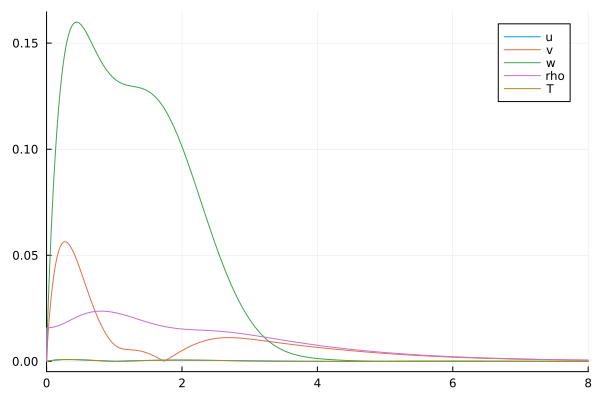

In [48]:
plot(x,abs.(vel[1]),label = "u",xlims=[0,8]) 
plot!(x,abs.(vel[2]),label = "v")
plot!(x,abs.(vel[3]),label = "w")
plot!(x,abs.(vel[4]),label = "rho")
plot!(x,abs.(vel[5]),label = "T") 

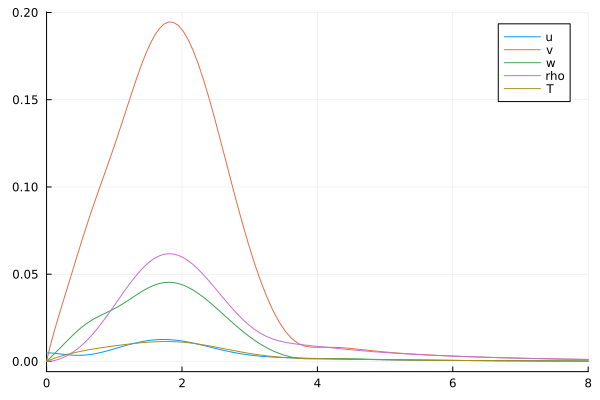

In [32]:
plot(x,abs.(vel_A[1]),label = "u",xlims=[0,8]) 
plot!(x,abs.(vel_A[2]),label = "v")
plot!(x,abs.(vel_A[3]),label = "w")
plot!(x,abs.(vel_A[4]),label = "rho")
plot!(x,abs.(vel_A[5]),label = "T") 

In [9]:
using LinearAlgebra
using Plots
N = 2
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2))); 
a = 6
b = 0.6
c = 0.5
WCC = zeros(N+1,1)
for i=1:N+1
    WCC[i,1] =  (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
end
# for i=1:N+1
#     x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
#     if x[i] > 40
#         x[i] = 40
#     end
# end

In [10]:
x

3×1 Matrix{Float64}:
 -1.0
 -6.123233995736766e-17
  1.0

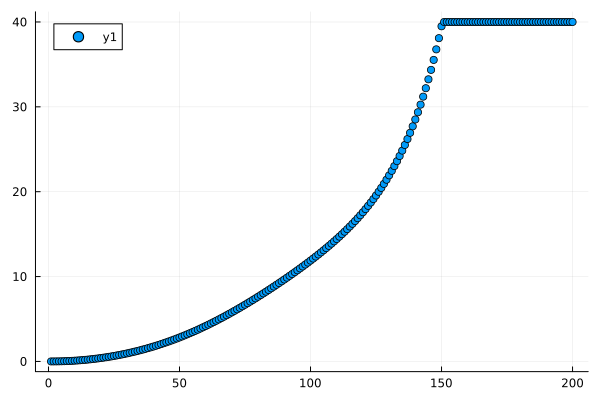

In [28]:
scatter(x)